# **<a href="https://bsginstitute.com/">BSG Institute</a>**

## **SESION 04: Manipulación y tratamiento de datos con Python**

### Tito Reategui - treateguig@bsginstitue.com

### **Tratamiento de datos: Calidad antes del modelamiento en Machine Learning**

La calidad de los datos es el factor más determinante del éxito de cualquier modelo de ML.  
Un buen modelo con datos deficientes produce resultados poco confiables (“garbage in, garbage out”). Por eso, entre el 60-80% del tiempo de un proyecto se dedica al preprocesamiento.



### 1. Evaluación inicial de calidad

-  Dimensión de los datos: filas, columnas, tipos de variables.  
-  Completitud: porcentaje de valores faltantes por variable.  
-  Consistencia: duplicados, formatos erróneos, rangos imposibles.  
-  Distribución: estadísticos descriptivos (media, mediana, desviación, percentiles).  
  Visualización: histogramas, boxplots, pairplots y matriz de correlación.  

### 2. Tratamiento de valores faltantes (Missing Values)

-  Eliminar registros o variables solo si el porcentaje es bajo (<5-10%) y no se pierde información crítica.  

-  Imputación (las más usadas):
    - Numéricas: media/mediana (simple), KNNImputer, IterativeImputer (MICE), o modelos predictivos.
    - Categóricas: moda, “Missing” como nueva categoría, o imputación avanzada.
    - Series de tiempo: forward/backward fill, interpolación.

Siempre **documentar** qué se imputó y crear una variable indicadora de “faltante” (missing flag), ya que a veces el hecho de faltar es informativo.

### 3. Tratamiento de valores extremos (Outliers)

-  Detectar: IQR (Q1-1.5×IQR y Q3+1.5×IQR), Z-score (>3), Isolation Forest, DBSCAN.  

-  Opciones:
    - Eliminar (solo si son errores claros y pocos).
    - Capping/Winsorizing (recortar al percentil 1-99 o 5-95).
    - Transformación (log, raíz cuadrada, Box-Cox, Yeo-Johnson).
    - Modelos robustos (que toleran outliers: árboles, XGBoost, etc.).

### 4. Otras prácticas importantes

-  Codificación de variables categóricas (One-Hot, Target Encoding, WOE para crédito).  
-  Escalado (StandardScaler, MinMaxScaler, RobustScaler —este último es mejor con outliers).  
-  Feature Engineering y selección de variables.  
-  Balanceo de clases (SMOTE, undersampling, class weights).  
-  División estratificada train/validation/test desde el principio.  

In [ ]:
# %pip install missingno

In [1]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
import missingno as msno
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

df = pd.read_csv('train.csv')  # Asume el archivo local

In [2]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000




5 Ejercicios con código:

Identificar patrón de missing:

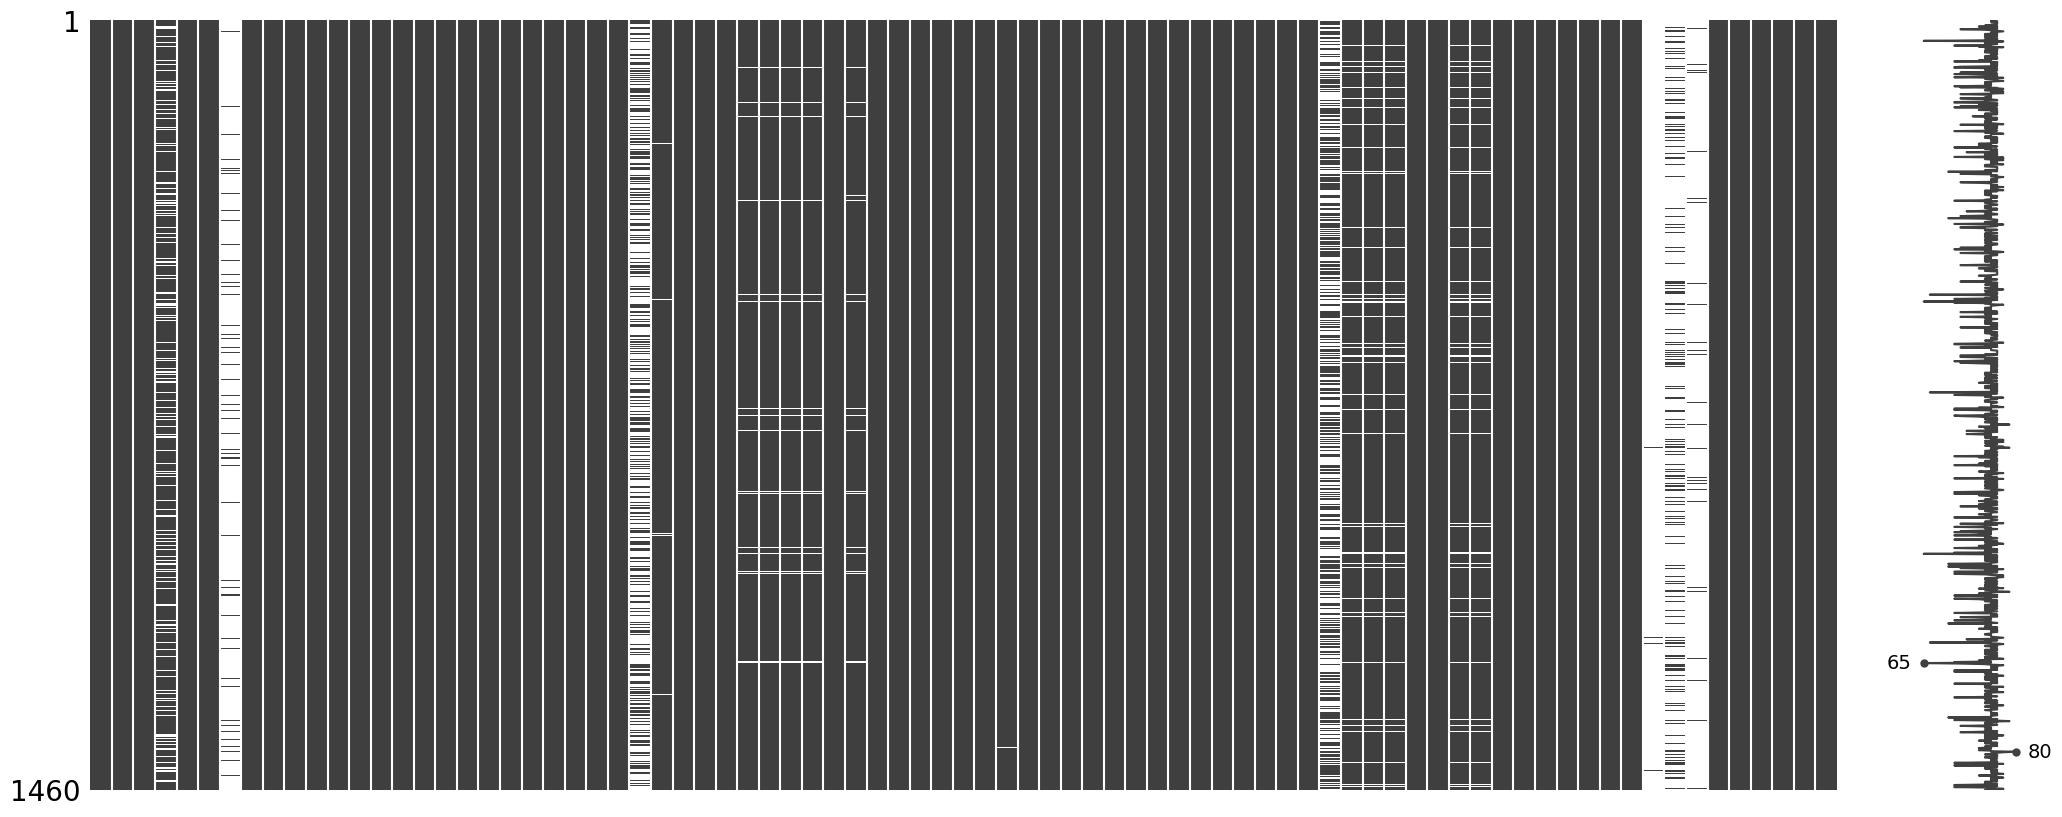

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageQual      0.055479
GarageFinish    0.055479
GarageType      0.055479
GarageYrBlt     0.055479
GarageCond      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtCond        0.025342
BsmtQual        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685
dtype: float64
   LotFrontage_missing  Alley_missing  MasVnrType_missing  \
0                    0              1                   0   
1                    0              1                   1   
2                    0              1                   0   
3                    0              1                   1   
4                    0              1                   0   

   FireplaceQu_missing  PoolQC_missing  Fence_missing  MiscFeature_missing  
0                    1               1              1             

In [3]:
msno.matrix(df)
plt.show()
missing_perc = df.isnull().mean().sort_values(ascending=False)
print(missing_perc[missing_perc > 0])

#Crear columnas de indicadores:

missing_cols = ['LotFrontage', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
for col in missing_cols:
    df[f'{col}_missing'] = df[col].isna().astype(int)
print(df[[f'{col}_missing' for col in missing_cols]].head())

# Imputar LotFrontage con KNN agrupado por Neighborhood:

# Agrupar y aplicar KNN por grupo
def knn_impute_grouped(df, group_col, impute_col):
    imputer = KNNImputer(n_neighbors=5)
    for group in df[group_col].unique():
        mask = df[group_col] == group
        df.loc[mask, impute_col] = imputer.fit_transform(df.loc[mask, [impute_col]])
    return df

df = knn_impute_grouped(df, 'Neighborhood', 'LotFrontage')
print(df['LotFrontage'].isnull().sum())  # Debe ser 0

# Usar IterativeImputer para múltiples vars:

num_cols = ['GarageYrBlt', 'MasVnrArea']
cat_cols = ['BsmtQual']  # Convertir cat a num temporalmente
for col in cat_cols:
    df[col] = df[col].astype('category').cat.codes.replace(-1, np.nan)  # NaN to np.nan
imputer = IterativeImputer(random_state=42)
df[num_cols + cat_cols] = imputer.fit_transform(df[num_cols + cat_cols])
print(df[num_cols + cat_cols].isnull().sum())

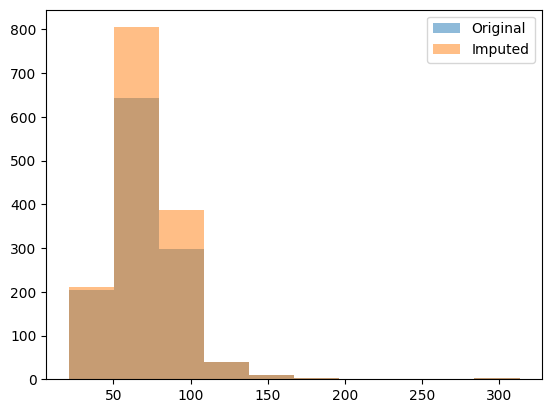

KS test: stat=0.0662353290066497, p=0.005807432702961765


In [4]:
#Comparar distribuciones antes/después:
original = pd.read_csv('train.csv')['LotFrontage'].dropna()
imputed = df['LotFrontage']
plt.hist(original, alpha=0.5, label='Original')
plt.hist(imputed, alpha=0.5, label='Imputed')
plt.legend(); plt.show()
ks_stat, p_value = ks_2samp(original, imputed)
print(f'KS test: stat={ks_stat}, p={p_value}')  # p > 0.05 indica similitud

2. Ingeniería de Características (Feature Engineering)
Profundización: En ML, features crudas a menudo no capturan relaciones no lineales.    
La ingeniería crea vars más predictivas (e.g., interacciones para sinergias).    
Polinómicas capturan curvas; agregaciones por grupo reducen ruido.

Ratios normalizan escalas.

Target encoding usa info del target pero con smoothing para evitar overfitting/leakage (usa CV).    

Importante: aumenta performance (e.g., R²); pitfalls: multicolinealidad nueva, leakage si no se hace en train/valid splits.

En housing, features como Age capturan depreciación temporal.
Código base:

In [6]:
!pip install category_encoders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.7 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
from category_encoders import TargetEncoder
from sklearn.preprocessing import PolynomialFeatures

#Crear TotalSF y Age:

df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']
df['Age'] = df['YrSold'] - df['YearBuilt']
print(df[['TotalSF', 'Age']].head())

#Crear bins de YearBuilt:

df['YearBuilt_bin'] = pd.qcut(df['YearBuilt'], q=5, labels=['VeryOld', 'Old', 'Medium', 'New', 'VeryNew'])
print(df['YearBuilt_bin'].value_counts())

# Target Encoding para Neighborhood con smoothing:

encoder = TargetEncoder(smoothing=5)
df['Neighborhood_encoded'] = encoder.fit_transform(df['Neighborhood'], df['SalePrice'])
print(df[['Neighborhood', 'Neighborhood_encoded']].head())

# Feature de interacción:

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
interact = poly.fit_transform(df[['OverallQual', 'GrLivArea']])
df['Qual_LivArea_interact'] = interact[:, 2]  # Solo interacción
print(df['Qual_LivArea_interact'].head())

# Feature de ratio:

df['GarageArea_per_Car'] = df['GarageArea'] / df['GarageCars'].replace(0, np.nan)  # Evitar div/0
df['Bsmt_Lot_Ratio'] = df['TotalBsmtSF'] / df['LotArea']
df['GarageArea_per_Car'].fillna(0, inplace=True)  # Imputar 0 si no garage
print(df[['GarageArea_per_Car', 'Bsmt_Lot_Ratio']].head())

ModuleNotFoundError: No module named 'category_encoders'

3. Codificación de Variables Categóricas   

Profundización: Categóricas no numéricas rompen modelos lineales.

OneHot infla dims (curse of dimensionality)

Ordinal preserva orden

Target usa correlación pero riesgo de leakage (usa k-fold).

Frequency encoding para alta cardinalidad evita dummies.

Hashing para muy alta (e.g., >100 cats).
En ML: previene underfitting.

pitfalls: leakage en target enc, dummies en alta card. En este dataset, Neighborhood (25) beneficia de target enc.
Código base:

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders import TargetEncoder, CountEncoder


# OneHot para baja card:

low_card_cols = ['Street', 'LotShape', 'Utilities']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = pd.DataFrame(ohe.fit_transform(df[low_card_cols]), columns=ohe.get_feature_names_out())
df = pd.concat([df, encoded], axis=1).drop(low_card_cols, axis=1)
print(df.head())

# Target Encoding para Neighborhood:

encoder = TargetEncoder()
df['Neighborhood_encoded'] = encoder.fit_transform(df['Neighborhood'], df['SalePrice'])
print(df['Neighborhood_encoded'].head())

# Frequency Encoding para Exterior*:

encoder = CountEncoder(normalize=True)  # Frequency
df['Exterior1st_freq'] = encoder.fit_transform(df['Exterior1st'])
df['Exterior2nd_freq'] = encoder.fit_transform(df['Exterior2nd'])
print(df[['Exterior1st_freq', 'Exterior2nd_freq']].head())

# Ordinal para qualities:

qual_map = {'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5, np.nan:0}
qual_cols = ['ExterQual', 'KitchenQual', 'BsmtQual']
for col in qual_cols:
    df[col] = df[col].map(qual_map)
print(df[qual_cols].head())

#  Mean Encoding con k-fold para GarageType (simulando no leakage):

from sklearn.model_selection import KFold
kf = KFold(n_splits=5)
df['GarageType_encoded'] = np.nan
for train_idx, val_idx in kf.split(df):
    train = df.iloc[train_idx]
    mean_enc = train.groupby('GarageType')['SalePrice'].mean()
    df.iloc[val_idx, df.columns.get_loc('GarageType_encoded')] = df.iloc[val_idx]['GarageType'].map(mean_enc)
df['GarageType_encoded'].fillna(df['SalePrice'].mean(), inplace=True)  # Global mean for unseen
print(df['GarageType_encoded'].head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Alley LandContour LotConfig  \
0   1          60       RL         65.0     8450   NaN         Lvl    Inside   
1   2          20       RL         80.0     9600   NaN         Lvl       FR2   
2   3          60       RL         68.0    11250   NaN         Lvl    Inside   
3   4          70       RL         60.0     9550   NaN         Lvl    Corner   
4   5          60       RL         84.0    14260   NaN         Lvl       FR2   

  LandSlope Neighborhood  ... GarageArea_per_Car Bsmt_Lot_Ratio Street_Grvl  \
0       Gtl      CollgCr  ...         274.000000       0.101302         0.0   
1       Gtl      Veenker  ...         230.000000       0.131458         0.0   
2       Gtl      CollgCr  ...         304.000000       0.081778         0.0   
3       Gtl      Crawfor  ...         214.000000       0.079162         0.0   
4       Gtl      NoRidge  ...         278.666667       0.080295         0.0   

  Street_Pave  LotShape_IR1  LotShape_IR2  L


4. Detección y Tratamiento de Outliers + Escalado


Profundización: Outliers sesgan modelos sensibles (e.g., linear reg).

IQR/Z-score detectan

IsolationForest para multivariado.

Tratamientos: winsor (cap) preserva datos.
transforms (log) normalizan para ML asumiendo gaussianidad (e.g., gradient boosting).

Escaladores: Standard asume normal
Robust ignora outliers
Power para sesgo. En ML: mejora estabilidad. pitfalls: remover outliers

genuinos pierde info; siempre escala post-split. En housing, GrLivArea tiene outliers grandes.
Código base:

91
           SalePrice  SalePrice_winsor
count    1460.000000       1460.000000
mean   180921.195890     179955.984932
std     79442.502883      74201.572198
min     34900.000000      61000.000000
25%    129975.000000     129975.000000
50%    163000.000000     163000.000000
75%    214000.000000     214000.000000
max    755000.000000     446261.000000


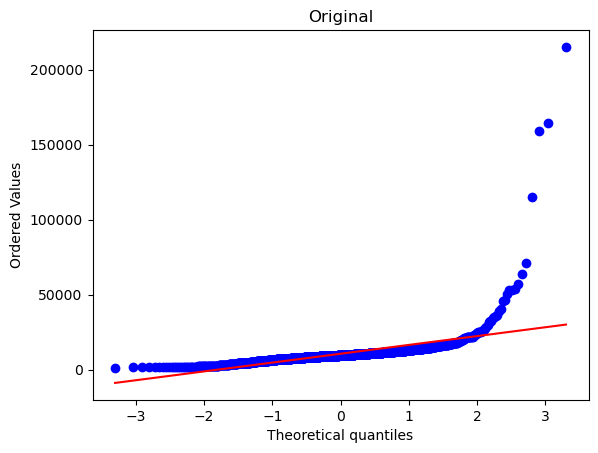

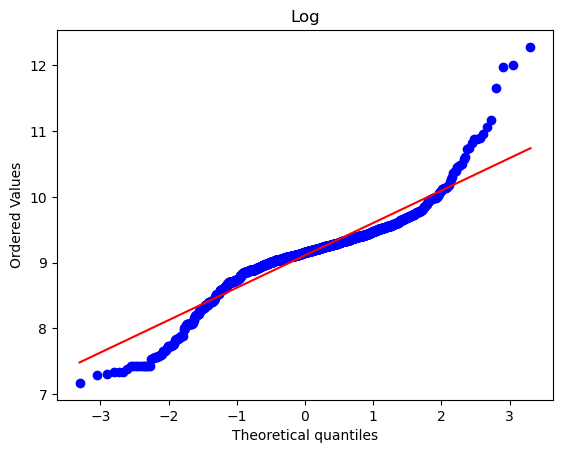

LotArea       0.026569
GrLivArea     0.000171
GarageArea   -0.328235
dtype: float64


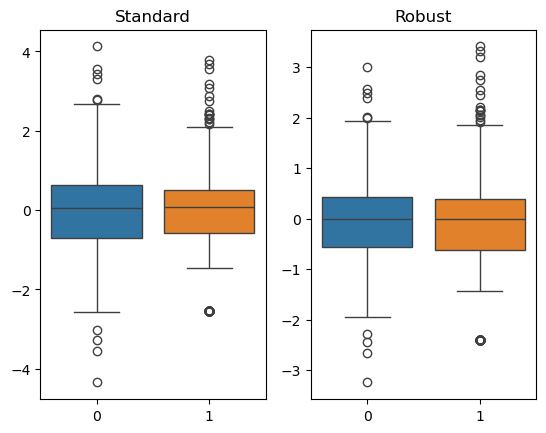

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, StandardScaler, PowerTransformer
from sklearn.ensemble import IsolationForest
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Detectar outliers IQR:

def detect_iqr_outliers(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)

outliers_lot = detect_iqr_outliers(df['LotArea'])
outliers_gr = detect_iqr_outliers(df['GrLivArea'])
print(df[outliers_lot | outliers_gr].shape[0])  # Num outliers

# Winsorización en SalePrice:

from scipy.stats.mstats import winsorize
df['SalePrice_winsor'] = winsorize(df['SalePrice'], limits=[0.01, 0.01])
print(df[['SalePrice', 'SalePrice_winsor']].describe())

#  Transform log y QQ-plot:

df['LotArea_log'] = np.log1p(df['LotArea'])
stats.probplot(df['LotArea'], dist="norm", plot=plt); plt.title('Original'); plt.show()
stats.probplot(df['LotArea_log'], dist="norm", plot=plt); plt.title('Log'); plt.show()

#  PowerTransformer para sesgadas:

skewed_cols = ['LotArea', 'GrLivArea', 'GarageArea']  # Asume sesgo >0.5
pt = PowerTransformer(method='yeo-johnson')
df[skewed_cols] = pt.fit_transform(df[skewed_cols])
print(df[skewed_cols].skew())  # Debe reducirse

# Comparar scalers:

cols = ['GrLivArea', 'GarageArea']
std = StandardScaler().fit_transform(df[cols])
rob = RobustScaler().fit_transform(df[cols])
fig, ax = plt.subplots(1,2)
sns.boxplot(data=std, ax=ax[0]); ax[0].set_title('Standard')
sns.boxplot(data=rob, ax=ax[1]); ax[1].set_title('Robust')
plt.show()

5. Análisis Avanzado de Correlación y Selección de Características   

Profundización: Correlación mide linealidad (Pearson) vs monotonicidad (Spearman);

multicolinealidad (VIF>5-10) causa inestabilidad en coefs.

Selección: univariada filtra ruido; recursiva (RFE) usa modelo; Boruta/BorutaPy para RF.

En ML: reduce dims, previene overfitting; pitfalls: ignorar no-lineales, seleccionar pre-split causa bias. En este dataset, GarageCars y GarageArea son colineales.
Código base:

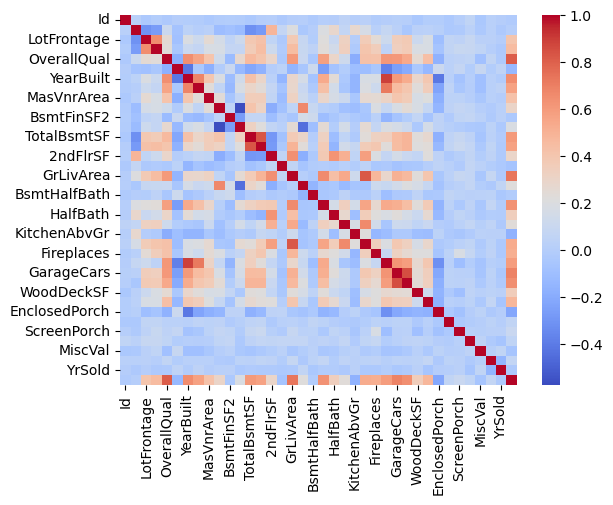

SalePrice      1.000000
OverallQual    0.809829
GrLivArea      0.731310
GarageCars     0.690711
YearBuilt      0.652682
GarageArea     0.649379
FullBath       0.635957
TotalBsmtSF    0.602725
GarageYrBlt    0.593788
1stFlrSF       0.575408
Name: SalePrice, dtype: float64
          feature           VIF
11      BsmtUnfSF           inf
9      BsmtFinSF1           inf
16      GrLivArea           inf
15   LowQualFinSF           inf
14       2ndFlrSF           inf
13       1stFlrSF           inf
12    TotalBsmtSF           inf
10     BsmtFinSF2           inf
36         YrSold  2.213617e+04
7    YearRemodAdd  2.112359e+04
6       YearBuilt  1.736564e+04
23   TotRmsAbvGrd  8.363272e+01
4     OverallQual  6.696856e+01
5     OverallCond  4.156475e+01
26     GarageCars  4.001241e+01
22   KitchenAbvGr  3.791103e+01
25    GarageYrBlt  3.274387e+01
27     GarageArea  3.127437e+01
21   BedroomAbvGr  3.082362e+01
19       FullBath  2.645425e+01
35         MoSold  6.648760e+00
2     LotFrontage  4.523

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv') # Added to define df

# Correlación Spearman y heatmap:

num_df = df.select_dtypes(include=np.number)
corr = num_df.corr(method='spearman')['SalePrice'].sort_values(ascending=False)
sns.heatmap(num_df.corr(method='spearman'), cmap='coolwarm')
plt.show()
print(corr.head(10))

# Calcular VIF y eliminar:

X = num_df.drop('SalePrice', axis=1).fillna(0)  # Imputar para VIF
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
high_vif = vif_data[vif_data['VIF'] > 10]['feature']
df.drop(high_vif, axis=1, inplace=True)
print(vif_data.sort_values('VIF', ascending=False))

# SelectKBest con f_regression:

X = num_df.drop('SalePrice', axis=1).fillna(0)
y = df['SalePrice']
selector = SelectKBest(f_regression, k=20)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print(selected_features)

# RFE con LinearRegression:

model = LinearRegression()
rfe = RFE(model, n_features_to_select=20)
rfe.fit(X, y)
selected = X.columns[rfe.support_]
print(selected)

# Permutation Importance con RF:

model = RandomForestRegressor(random_state=42)
model.fit(X, y)
perm = permutation_importance(model, X, y, n_repeats=10, random_state=42)
imp_df = pd.DataFrame({'feature': X.columns, 'importance': perm.importances_mean}).sort_values('importance', ascending=False)
print(imp_df.head(10))

6. Preparación para Modelado ML: Pipelines, Validación Cruzada y Evaluación


Profundización: Pipelines encapsulan pasos para reproducibilidad y evitan leakage (e.g., fit en train, transform en test).

ColumnTransformer maneja tipos mixtos. CV (KFold) estima performance real.

Stratified para clasificación, pero aquí KFold ok.

Métricas: RMSE penaliza grandes errores (bueno para precios).

RMSLE para logs (maneja escalas).

Learning curves detectan under/overfit. En ML: asegura generalización;

pitfalls: no CV causa optimismo bias; usa neg_ para scorers en sklearn.
Código base para pipelines:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, RobustScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

# ========================== CARGA ==========================
df = pd.read_csv('train.csv')
X = df.drop('SalePrice', axis=1)
y = df['SalePrice'].copy()

# ========================== COLUMNAS ==========================
num_cols = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
            'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
            '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
            'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
            'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch',
            'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

cat_cols = ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
            'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
            'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual',
            'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
            'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
            'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
            'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

# ========================== PIPELINE  ==========================
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),      # Más estable que IterativeImputer al inicio
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', RobustScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
], remainder='drop')

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

# ========================== RMSLE SCORER ==========================
def rmsle(y_true, y_pred):
    y_true = np.log1p(y_true)
    y_pred = np.log1p(np.clip(y_pred, 0, None))   # Evita log de negativos
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

# ========================== EVALUACIÓN ==========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)   # 5 folds para que sea más rápido

scores_rmsle = cross_val_score(full_pipeline, X, y, cv=kf, scoring=rmsle_scorer)
print(f"CV RMSLE : { -scores_rmsle.mean():.5f} (±{scores_rmsle.std():.5f})")

# Train / Test final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

# Evitar NaNs o valores negativos en predicciones
y_pred = np.clip(y_pred, 0, None)

print("\nMétricas en conjunto de prueba:")
print(f"MAE   : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²    : {r2_score(y_test, y_pred):.4f}")
print(f"MAPE  : {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%")
print(f"RMSLE : {rmsle(y_test, y_pred):.5f}")

CV RMSLE : 0.27447 (±0.18359)

Métricas en conjunto de prueba:
MAE   : 19717.97
RMSE  : 31620.66
R²    : 0.8696
MAPE  : 12.53%
RMSLE : 0.63767


# Crear Variables

In [ ]:
# como veo si tiene piscina
# 5. HasPool: Indicador binario si tiene piscina
df['HasPool'] = (df['PoolArea'] > 0).astype(int)

In [ ]:

import pandas as pd
import numpy as np

# Cargar el dataset (asumiendo train.csv en el directorio actual)
df = pd.read_csv('train.csv')

# 1. TotalSF: Área total cuadrada (sótano + piso 1 + piso 2)
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# 2. HouseAge: Edad de la casa al momento de la venta
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# 3. RemodAge: Edad desde la última remodelación
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

# 4. TotalBath: Total de baños (completos + medios, incluyendo sótano)
df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                   df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

# 5. HasPool: Indicador binario si tiene piscina
df['HasPool'] = (df['PoolArea'] > 0).astype(int)

# 6. HasGarage: Indicador binario si tiene garaje
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

# 7. QualityProduct: Producto de calidad general y condición
df['QualityProduct'] = df['OverallQual'] * df['OverallCond']

# 8. PorchArea: Área total de porches
df['PorchArea'] = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                   df['3SsnPorch'] + df['ScreenPorch'])

# 9. LotRatio: Ratio de frente de lote sobre área de lote (imputar NaN en LotFrontage si necesario)
df['LotFrontage'].fillna(df['LotFrontage'].median(), inplace=True)
df['LotRatio'] = df['LotFrontage'] / df['LotArea']

# 10. ExterQualScore: Puntuación numérica de calidad exterior (mapeo ordinal)
qual_map = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
df['ExterQualScore'] = df['ExterQual'].map(qual_map)

# Mostrar las nuevas columnas
print(df[['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'HasPool', 'HasGarage',
          'QualityProduct', 'PorchArea', 'LotRatio', 'ExterQualScore']].head())

# Opcional: Guardar el df actualizado
# df.to_csv('train_engineered.csv', index=False)

   TotalSF  HouseAge  RemodAge  TotalBath  HasPool  HasGarage  QualityProduct  \
0     2566         5         5        3.5        0          1              35   
1     2524        31        31        2.5        0          1              48   
2     2706         7         6        3.5        0          1              35   
3     2473        91        36        2.0        0          1              35   
4     3343         8         8        3.5        0          1              40   

   PorchArea  LotRatio  ExterQualScore  
0         61  0.007692               4  
1          0  0.008333               3  
2         42  0.006044               4  
3        307  0.006283               3  
4         84  0.005891               4  


**1. Definición del diccionario (qual_map)**

Se crea un diccionario que asigna un valor numérico a una categoría de texto. Estas categorías suelen representar una escala de calidad (comúnmente vista en datasets de bienes raíces como el de Boston o Ames Housing):

+    Po (Poor / Pobre): 1
+   Fa (Fair / Regular): 2
+    TA (Typical-Average / Promedio): 3
+    Gd (Good / Bueno): 4
+    Ex (Excellent / Excelente): 5





2. **Transformación de los datos (`.map()`)**

La función `.map(qual_map)` recorre la columna existente llamada `ExterQual` (que contiene texto) y sustituye cada valor por su número correspondiente definido en el diccionario.

3. **Creación de la nueva columna**

El resultado se guarda en una nueva columna llamada `ExterQualScore`. De esta forma, conservas la columna original pero generas una versión numérica que los algoritmos matemáticos pueden procesar.

**¿Por qué se hace esto?**

Los modelos de Machine Learning (como una regresión lineal) no pueden "leer" palabras, solo números. Al usar un mapeo ordinal en lugar de números aleatorios, le estás diciendo al modelo que hay un **orden lógico**: que "Excelente" (5) es superior a "Bueno" (4), y así sucesivamente.

**Ejemplo de cómo se vería el cambio**:

    ExterQual(Original) ExterQualScore(Resultado)
      Ex                        5
      TA                        3
      Gd                        4
      Po                        1

### Análisis exploratorio

In [ ]:
# Traemos las librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Cargar el dataset (asumiendo train.csv en el directorio actual)
df = pd.read_csv('train.csv')

# Agregar las 10 variables nuevas de ingeniería de features (del código anterior)
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

df['HouseAge'] = df['YrSold'] - df['YearBuilt']

df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                   df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

df['HasPool'] = (df['PoolArea'] > 0).astype(int)

df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

df['QualityProduct'] = df['OverallQual'] * df['OverallCond']

df['PorchArea'] = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                   df['3SsnPorch'] + df['ScreenPorch'])

df['LotFrontage'].fillna(df['LotFrontage'].median(), inplace=True)

df['LotRatio'] = df['LotFrontage'] / df['LotArea']

qual_map = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

df['ExterQualScore'] = df['ExterQual'].map(qual_map)

In [ ]:
print(qual_map)
type(qual_map)

{'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}


dict

In [ ]:
#verificamos
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,TotalSF,HouseAge,RemodAge,TotalBath,HasPool,HasGarage,QualityProduct,PorchArea,LotRatio,ExterQualScore
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,2566,5,5,3.5,0,1,35,61,0.007692,4
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,2524,31,31,2.5,0,1,48,0,0.008333,3
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,2706,7,6,3.5,0,1,35,42,0.006044,4
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,2473,91,36,2.0,0,1,35,307,0.006283,3
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,3343,8,8,3.5,0,1,40,84,0.005891,4


In [ ]:
# Preparación: Manejar missing values simples para análisis
df.fillna(0, inplace=True)  # Imputación básica para análisis (ajusta según necesidades)

# Separar variables numéricas y categóricas (incluyendo nuevas)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('SalePrice')  # Excluir target
cat_cols = df.select_dtypes(include=['object']).columns
target = 'SalePrice'

print("Variables numéricas:", num_cols.tolist())
print("Variables categóricas:", cat_cols.tolist())

Variables numéricas: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'HasPool', 'HasGarage', 'QualityProduct', 'PorchArea', 'LotRatio', 'ExterQualScore']
Variables categóricas: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',

In [ ]:
# Muestra la suma de valores nulos para cada columna
print(df.isnull().sum())

Id                0
MSSubClass        0
MSZoning          0
LotFrontage       0
LotArea           0
                 ..
HasGarage         0
QualityProduct    0
PorchArea         0
LotRatio          0
ExterQualScore    0
Length: 91, dtype: int64


In [ ]:
# Cuenta nulos solo en las columnas de calidad
nulos_calidad = df[['ExterQual', 'ExterQualScore']].isnull().sum()
print(nulos_calidad)

ExterQual         0
ExterQualScore    0
dtype: int64


**Nota importante:** Si ExterQual tenía un valor como "None" o "Missing" y no lo incluiste en el diccionario qual_map, la función .map() pondrá un NaN (nulo) automáticamente en la nueva columna.

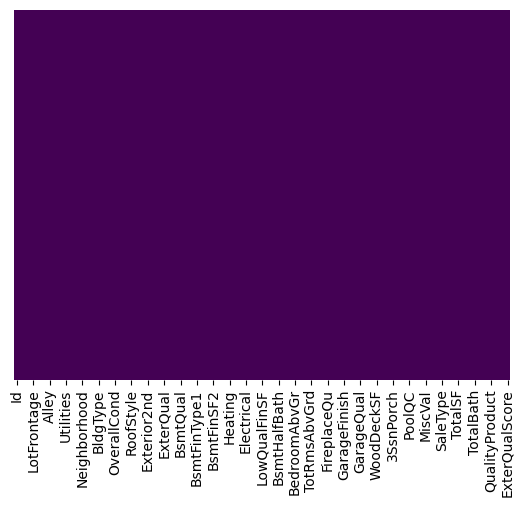

In [ ]:
# Visualización rápida (Recomendado para datasets grandes)
import seaborn as sns
import matplotlib.pyplot as plt

# Crea un mapa de calor donde las líneas blancas indican valores nulos
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.show()

1. La lógica de ordenamiento (sorted)
La línea más compleja es la que genera la lista top_pearson:

+  corr_pearson.items(): Convierte el diccionario de correlaciones en una lista de tuplas. Cada tupla tiene el formato: ('NombreColumna', (coeficiente, p-value)).

    +  key=lambda x: abs(x[1][0]): Esta es la regla de ordenamiento.

    +  x[1] accede a la tupla de valores (coeficiente, p-value).

    +  x[1][0] selecciona específicamente el coeficiente de Pearson.

+  abs(...): Aplica el valor absoluto. Esto es crucial porque en bienes raíces existen correlaciones negativas potentes (ej. "Antigüedad de la casa" vs "Precio") que son tan importantes como las positivas.

+  reverse=True: Ordena de mayor a mayor impacto (descendente).

+  [:10]: Realiza un slicing para conservar solo los primeros 10 elementos de la lista resultante.

In [ ]:
# --- Análisis Bivariado ---
# Objetivo: Relación entre cada feature y 'SalePrice'
print("\n=== Análisis Bivariado ===")

# 1. Correlación para numéricas (Pearson y Spearman) con p-values
corr_pearson = {}
corr_spearman = {}
for col in num_cols:
    pearson_coef, p_val = pearsonr(df[col], df[target])
    spearman_coef, s_p_val = spearmanr(df[col], df[target])
    corr_pearson[col] = (pearson_coef, p_val)
    corr_spearman[col] = (spearman_coef, s_p_val)

# Top 10 correlaciones Pearson (absolutas)
top_pearson = sorted(corr_pearson.items(), key=lambda x: abs(x[1][0]), reverse=True)[:10]
print("\nTop 10 correlaciones Pearson con SalePrice (coef, p-value):")
for col, (coef, p) in top_pearson:
    print(f"{col}: {coef:.3f} (p={p:.3e})")


=== Análisis Bivariado ===

Top 10 correlaciones Pearson con SalePrice (coef, p-value):
OverallQual: 0.791 (p=2.186e-313)
TotalSF: 0.782 (p=5.511e-302)
GrLivArea: 0.709 (p=4.518e-223)
ExterQualScore: 0.683 (p=7.332e-201)
GarageCars: 0.640 (p=2.499e-169)
TotalBath: 0.632 (p=1.880e-163)
GarageArea: 0.623 (p=5.265e-158)
TotalBsmtSF: 0.614 (p=9.484e-152)
1stFlrSF: 0.606 (p=5.395e-147)
QualityProduct: 0.565 (p=4.701e-124)


In [ ]:
import numpy as np
X = np.array([[np.nan, 0, 3],
[3, 7, 9],
[3, 5, 2],
[4, np.nan, 6],
[8, 8, 1]])
y = np.array([14, 16, -1, 8, -5])

In [ ]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='mean') # Otras opciones: 'median',
'most_frequent', 'constant'
X2 = imp.fit_transform(X)
print(X2)

[[4.5 0.  3. ]
 [3.  7.  9. ]
 [3.  5.  2. ]
 [4.  5.  6. ]
 [8.  8.  1. ]]


In [ ]:
# Modelo
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X2, y)
print(model.predict(X2))

[13.14869292 14.3784627  -1.15539732 10.96606197 -5.33782027]


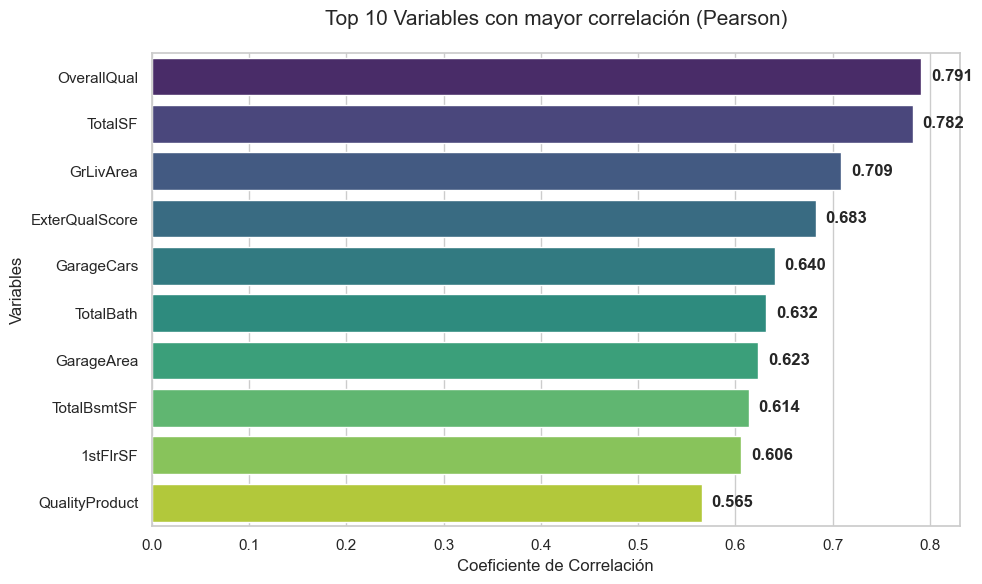

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos para el gráfico
# Extraemos los nombres y los coeficientes del top_pearson que ya calculaste
labels = [x[0] for x in top_pearson]
values = [x[1][0] for x in top_pearson]

# 2. Configurar el estilo y el tamaño
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Crear el gráfico de barras
# Usamos un mapa de colores (diverging palette) para resaltar la intensidad
ax = sns.barplot(x=values, y=labels, palette="viridis")

# 4. Añadir etiquetas y título
plt.title('Top 10 Variables con mayor correlación (Pearson)', fontsize=15, pad=20)
plt.xlabel('Coeficiente de Correlación', fontsize=12)
plt.ylabel('Variables', fontsize=12)

# 5. Añadir el valor numérico al final de cada barra para mayor claridad
for i, v in enumerate(values):
    ax.text(v + (0.01 if v > 0 else -0.05), i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

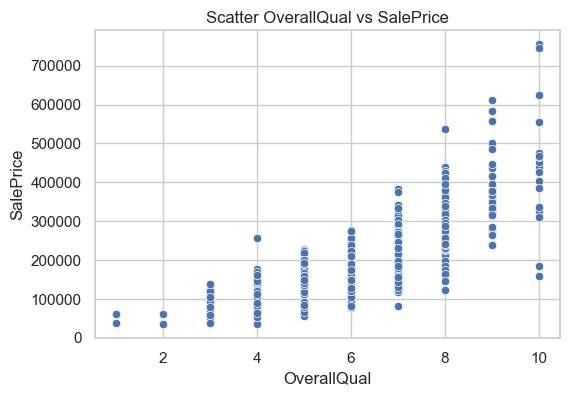

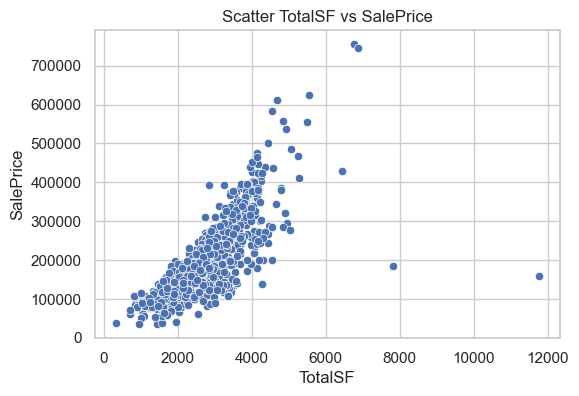

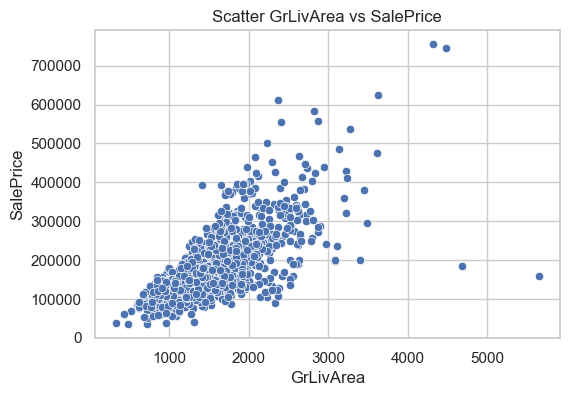

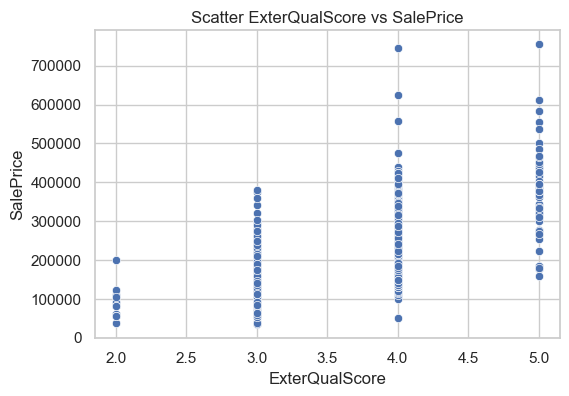

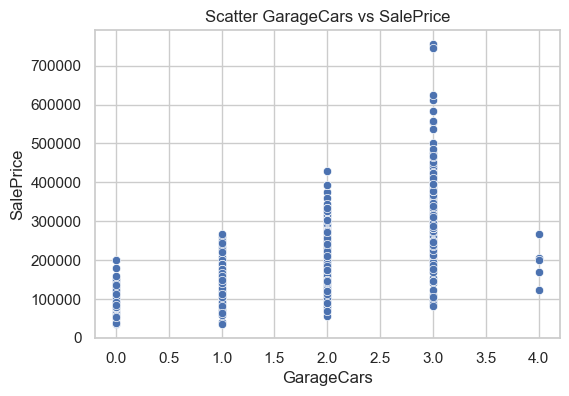

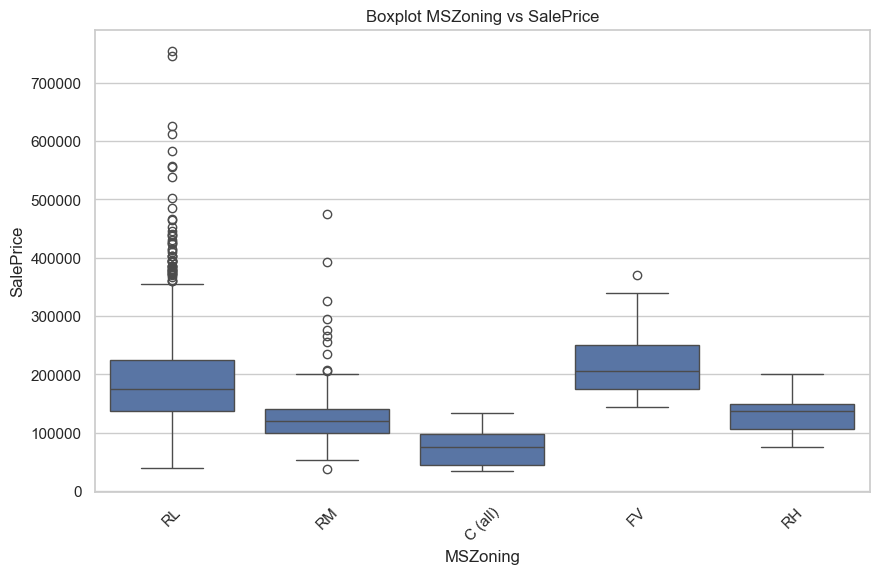

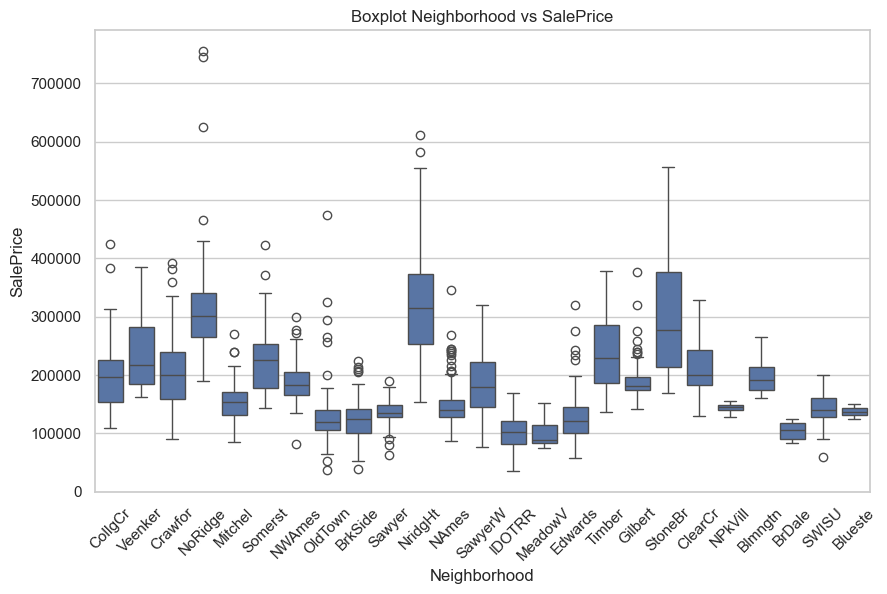

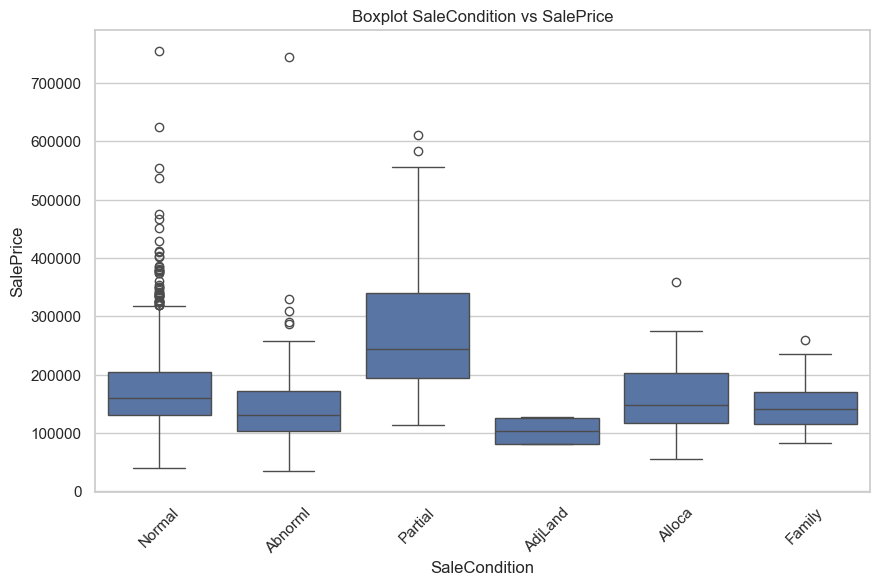


Categóricas significativas (ANOVA p-value < 0.05):
Neighborhood: p=1.559e-225
ExterQual: p=1.440e-204
BsmtQual: p=8.159e-196
KitchenQual: p=3.032e-192
GarageFinish: p=6.229e-115
FireplaceQu: p=2.971e-107
Foundation: p=5.792e-91
GarageType: p=6.117e-87
BsmtFinType1: p=2.386e-71
HeatingQC: p=2.667e-67

=== Análisis Multivariado ===


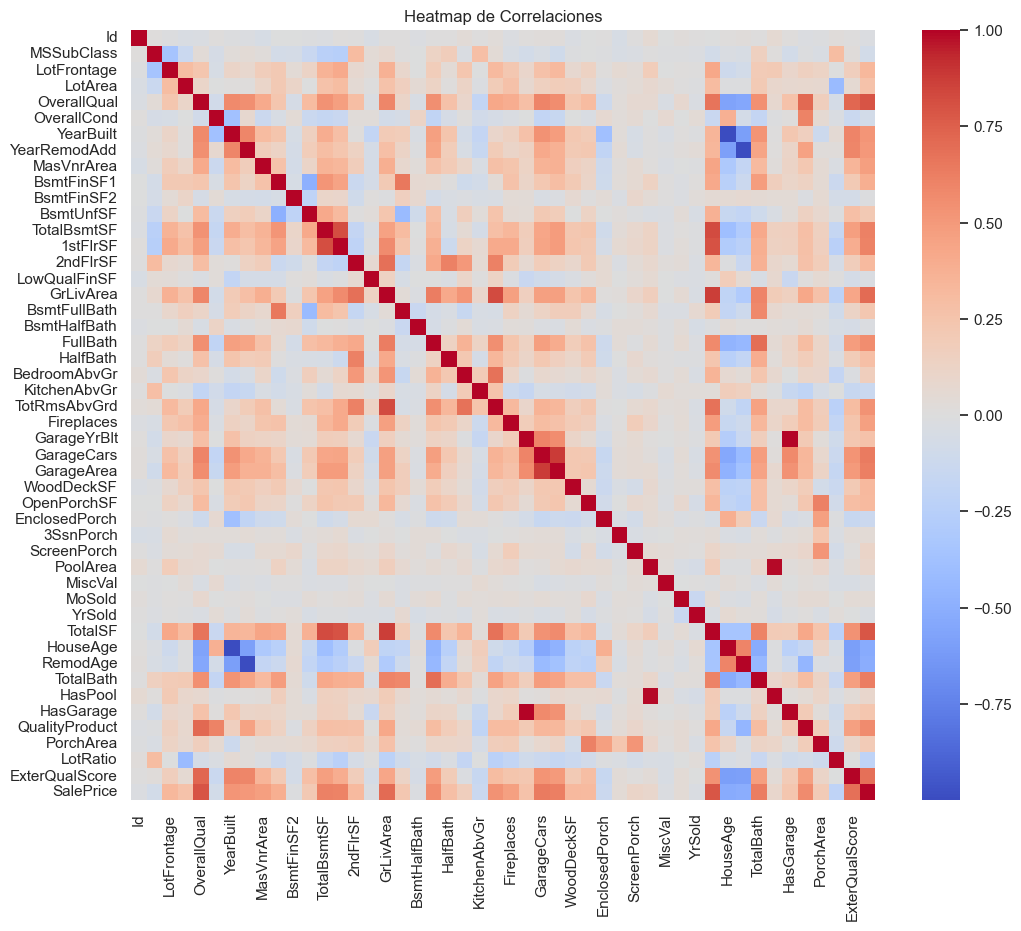


VIF (multicolinealidad >5-10 indica problema):
          feature  VIF
15   LowQualFinSF  inf
30  EnclosedPorch  inf
31      3SsnPorch  inf
32    ScreenPorch  inf
36         YrSold  inf
37        TotalSF  inf
38       HouseAge  inf
39       RemodAge  inf
40      TotalBath  inf
20       HalfBath  inf
Variables con alto VIF: ['LowQualFinSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'YrSold', 'TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'HalfBath', 'FullBath', 'BsmtHalfBath', 'BsmtFullBath', 'GrLivArea', 'OpenPorchSF', '2ndFlrSF', '1stFlrSF', 'TotalBsmtSF', 'BsmtUnfSF', 'BsmtFinSF2', 'BsmtFinSF1', 'YearRemodAdd', 'YearBuilt', 'PorchArea', 'GarageYrBlt', 'HasGarage', 'OverallQual', 'QualityProduct', 'OverallCond', 'ExterQualScore', 'TotRmsAbvGrd', 'HasPool', 'PoolArea', 'GarageCars', 'KitchenAbvGr', 'GarageArea', 'BedroomAbvGr', 'LotFrontage', 'LotRatio']

Top 10 Importancias de Features (Random Forest):
OverallQual       0.380777
TotalSF           0.364048
2ndFlrSF          0.02765

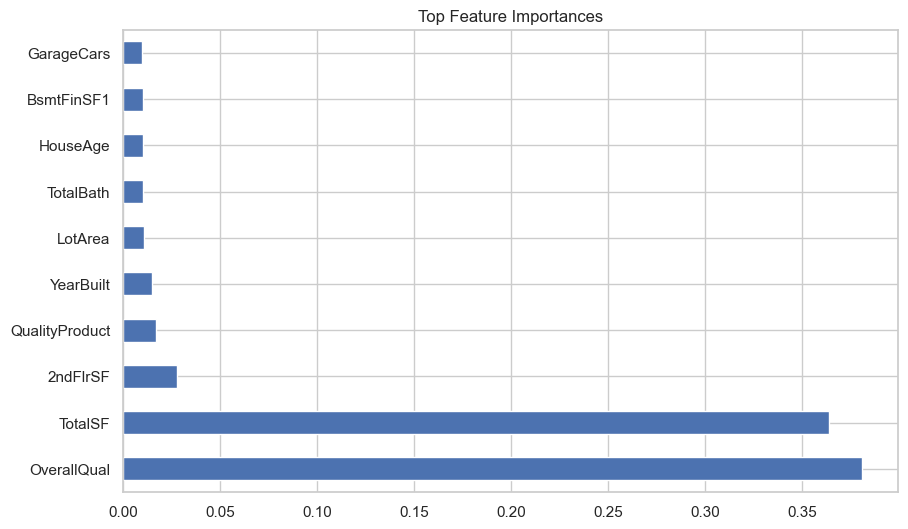


Varianza explicada acumulada por componentes PCA:
[0.07140906 0.10077789 0.12609729 0.14611721 0.16332544 0.17864222
 0.19301212 0.20643684 0.21916761 0.23133826]


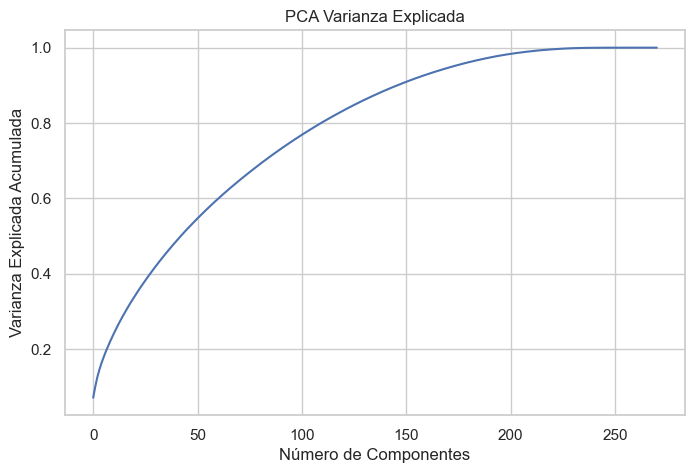


Variables relevantes sugeridas para modelado:
Numéricas (alta corr, bajo VIF): ['MasVnrArea', 'Fireplaces', 'WoodDeckSF']
Categóricas (significativas): ['Neighborhood', 'ExterQual', 'BsmtQual', 'KitchenQual', 'GarageFinish', 'FireplaceQu', 'Foundation', 'GarageType', 'BsmtFinType1', 'HeatingQC', 'MasVnrType', 'BsmtExposure', 'SaleCondition', 'Exterior1st', 'Exterior2nd', 'SaleType', 'MSZoning', 'HouseStyle', 'GarageQual', 'GarageCond', 'LotShape', 'CentralAir', 'PavedDrive', 'Electrical', 'RoofStyle', 'BsmtCond', 'Fence', 'BldgType', 'LandContour', 'BsmtFinType2', 'RoofMatl', 'Condition1', 'Alley', 'ExterCond', 'PoolQC', 'LotConfig', 'Functional', 'Heating', 'MiscFeature', 'Condition2']
De RF importance: ['OverallQual', 'TotalSF', '2ndFlrSF', 'QualityProduct', 'YearBuilt', 'LotArea', 'TotalBath', 'HouseAge']
Sugerencia: Usa top 20-30, elimina multicolineales, incluye nuevas como TotalSF, QualityProduct


In [ ]:
# --- Análisis Bivariado ---
# Visualización: Scatter plots para top 5 numéricas
top_num = [col for col, _ in top_pearson[:5]]
for col in top_num:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df[target])
    plt.title(f'Scatter {col} vs SalePrice')
    plt.show()

# 2. Para categóricas: Box plots y ANOVA (para significancia)
significant_cats = []
for col in cat_cols:
    # Codificar si necesario para ANOVA
    le = LabelEncoder()
    encoded = le.fit_transform(df[col].astype(str))
    groups = [df[target][encoded == i] for i in range(len(le.classes_))]
    groups = [g for g in groups if len(g) > 0]  # Evitar grupos vacíos
    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        if p_val < 0.05:
            significant_cats.append((col, p_val))

    # Box plot para top
    if col in ['Neighborhood', 'MSZoning', 'SaleCondition']:  # Ejemplos clave
        plt.figure(figsize=(10,6))
        sns.boxplot(x=df[col], y=df[target])
        plt.title(f'Boxplot {col} vs SalePrice')
        plt.xticks(rotation=45)
        plt.show()

# Top categóricas significativas
significant_cats.sort(key=lambda x: x[1])
print("\nCategóricas significativas (ANOVA p-value < 0.05):")
for col, p in significant_cats[:10]:
    print(f"{col}: p={p:.3e}")

# --- Análisis Multivariado ---
# Objetivo: Relaciones entre múltiples variables y relevancia para modelado
print("\n=== Análisis Multivariado ===")

# 1. Matriz de correlación (heatmap) para numéricas
plt.figure(figsize=(12,10))
num_df = df[num_cols.tolist() + [target]]
sns.heatmap(num_df.corr(), annot=False, cmap='coolwarm')
plt.title('Heatmap de Correlaciones')
plt.show()

# 2. VIF para multicolinealidad (en numéricas, excluyendo target)
X_num = df[num_cols].fillna(0)  # Imputar para VIF
vif_data = pd.DataFrame()
vif_data['feature'] = X_num.columns
vif_data['VIF'] = [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
vif_data.sort_values('VIF', ascending=False, inplace=True)
print("\nVIF (multicolinealidad >5-10 indica problema):")
print(vif_data.head(10))
high_vif = vif_data[vif_data['VIF'] > 10]['feature'].tolist()
print(f"Variables con alto VIF: {high_vif}")

# 3. Importancia de features con Random Forest (multivariado)
X = df.drop(target, axis=1)
# Codificar categóricas para modelo
X = pd.get_dummies(X, drop_first=True)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 Importancias de Features (Random Forest):")
print(importances.head(10))

# Visualización
plt.figure(figsize=(10,6))
importances.head(10).plot(kind='barh')
plt.title('Top Feature Importances')
plt.show()

# 4. PCA para reducción dimensional (insight multivariado)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.fillna(0))
pca = PCA()
pca.fit(X_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_)
print("\nVarianza explicada acumulada por componentes PCA:")
print(cum_var[:10])  # Primeros 10

plt.figure(figsize=(8,5))
plt.plot(cum_var)
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('PCA Varianza Explicada')
plt.show()

# 5. Indicadores de relevancia para modelado
# Basado en: corr >0.3, p<0.05, VIF<10, importance >0.01
relevant_num = [col for col, (coef, p) in corr_pearson.items() if abs(coef) > 0.3 and p < 0.05 and col not in high_vif]
relevant_cat = [col for col, p in significant_cats if p < 0.05]
relevant_from_rf = importances[importances > 0.01].index.tolist()

print("\nVariables relevantes sugeridas para modelado:")
print("Numéricas (alta corr, bajo VIF):", relevant_num)
print("Categóricas (significativas):", relevant_cat)
print("De RF importance:", relevant_from_rf[:10])
print("Sugerencia: Usa top 20-30, elimina multicolineales, incluye nuevas como TotalSF, QualityProduct")